In [50]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import MultiLabelBinarizer
import os
from collections import Counter

In [6]:
# baseline/tfidf_lr_baseline.py

class TFIDF_LR_Classifier:
    def __init__(self, max_features=10000, ngram_range=(1,2), C=1.0):
        self.vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
        #self.model = OneVsRestClassifier(LogisticRegression(C=C, solver='liblinear')) too slow! changed
        self.model = OneVsRestClassifier(
            LogisticRegression(C=C, solver='saga', max_iter=1000),
            n_jobs=-1  # parallel
        )
        self.mlb = MultiLabelBinarizer()

    def fit(self, texts, labels):
        print("Fitting TF-IDF vectorizer...")
        X = self.vectorizer.fit_transform(texts)
        Y = self.mlb.fit_transform(labels)
        print("Training Logistic Regression...")
        self.model.fit(X, Y)

    def predict(self, texts):
        X = self.vectorizer.transform(texts)
        Y_pred = self.model.predict(X)
        return self.mlb.inverse_transform(Y_pred)

    def predict_proba(self, texts):
        X = self.vectorizer.transform(texts)
        Y_scores = self.model.predict_proba(X)
        return Y_scores

    def evaluate(self, texts, labels):
        X = self.vectorizer.transform(texts)
        Y_true = self.mlb.transform(labels)
        Y_pred = self.model.predict(X)
        micro = f1_score(Y_true, Y_pred, average='micro')
        macro = f1_score(Y_true, Y_pred, average='macro')
        return {'micro_f1': micro, 'macro_f1': macro}

    def save(self, path_prefix):
        with open(path_prefix + '_vectorizer.pkl', 'wb') as f:
            pickle.dump(self.vectorizer, f)
        with open(path_prefix + '_model.pkl', 'wb') as f:
            pickle.dump(self.model, f)
        with open(path_prefix + '_mlb.pkl', 'wb') as f:
            pickle.dump(self.mlb, f)

    def load(self, path_prefix):
        with open(path_prefix + '_vectorizer.pkl', 'rb') as f:
            self.vectorizer = pickle.load(f)
        with open(path_prefix + '_model.pkl', 'rb') as f:
            self.model = pickle.load(f)
        with open(path_prefix + '_mlb.pkl', 'rb') as f:
            self.mlb = pickle.load(f)


In [9]:
# load
df = pd.read_pickle('../data/mimic3_data_test.pkl')
texts = df['TEXT'].tolist()
labels = df['ICD9_CODE'].tolist()

# divide into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(texts, labels, test_size=0.2, random_state=42)


In [ ]:
# initial model
clf = TFIDF_LR_Classifier(max_features=10000, ngram_range=(1,2), C=1.0)
clf.fit(X_train, y_train)


results = clf.evaluate(X_val, y_val)
print("Validation Micro-F1:", results['micro_f1'])
print("Validation Macro-F1:", results['macro_f1'])

clf.save('..models/tfidf_lr_baseline')

Fitting TF-IDF vectorizer...
Training Logistic Regression...


/opt/anaconda3/envs/ribonn/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/ribonn/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/ribonn/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/ribonn/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/ribonn/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/ribonn/lib/python3.9/site-pack

## The quick test baseline script：

✅ label: common top 100
✅ saga solver + multithread
✅ restirct training size
✅ output performance report

In [25]:

# === Step 1: loading ===
df = pd.read_pickle('../data/mimic3_data_test.pkl')

# === Step 2: choose top 100 label ===
all_labels = [code for label_list in df['ICD9_CODE'] for code in label_list]
top_labels = set([label for label, _ in Counter(all_labels).most_common(100)])

df['filtered_labels'] = df['ICD9_CODE'].apply(lambda codes: [c for c in codes if c in top_labels])
df = df[df['filtered_labels'].map(len) > 0]  

# === Step 3: train/valid ===
texts = df['TEXT'].tolist()
labels = df['filtered_labels'].tolist()
X_train, X_val, y_train, y_val = train_test_split(texts, labels, test_size=0.2, random_state=42)

X_train = X_train[:5000]
y_train = y_train[:5000]

# === Step 4: vectorize model train ===
print("Fitting TF-IDF vectorizer...")
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)

print("Binarizing labels...")
mlb = MultiLabelBinarizer()
Y_train_bin = mlb.fit_transform(y_train)

print(f"TF-IDF shape: {X_train_vec.shape}, Label shape: {Y_train_bin.shape}")

print("Training Logistic Regression...")
clf = OneVsRestClassifier(
    LogisticRegression(C=1.0, solver='saga', max_iter=1000),
    n_jobs=-1
)
clf.fit(X_train_vec, Y_train_bin)

# === Step 5: pred ===
X_val_vec = vectorizer.transform(X_val)
Y_val_bin = mlb.transform(y_val)
Y_val_pred = clf.predict(X_val_vec)

micro = f1_score(Y_val_bin, Y_val_pred, average='micro')
macro = f1_score(Y_val_bin, Y_val_pred, average='macro')

print(f"Validation Micro-F1: {micro:.4f}")
print(f"Validation Macro-F1: {macro:.4f}")


Fitting TF-IDF vectorizer...
Binarizing labels...
TF-IDF shape: (5000, 10000), Label shape: (5000, 100)
Training Logistic Regression...
Validation Micro-F1: 0.2177
Validation Macro-F1: 0.0680


/opt/anaconda3/envs/ribonn/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


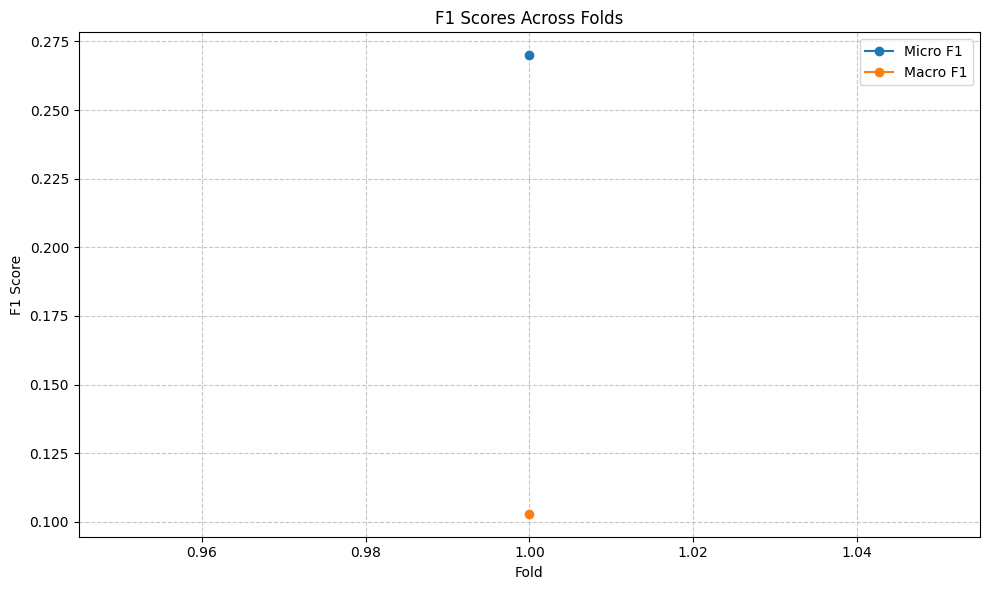

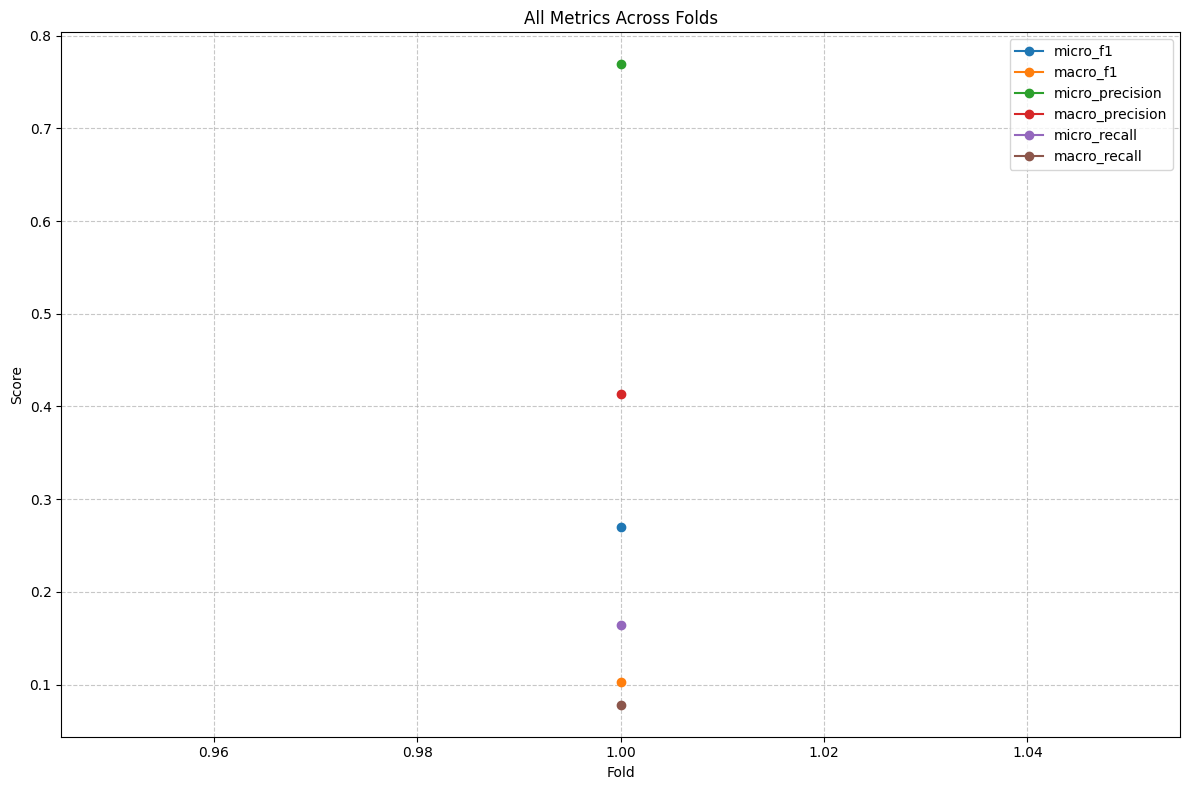

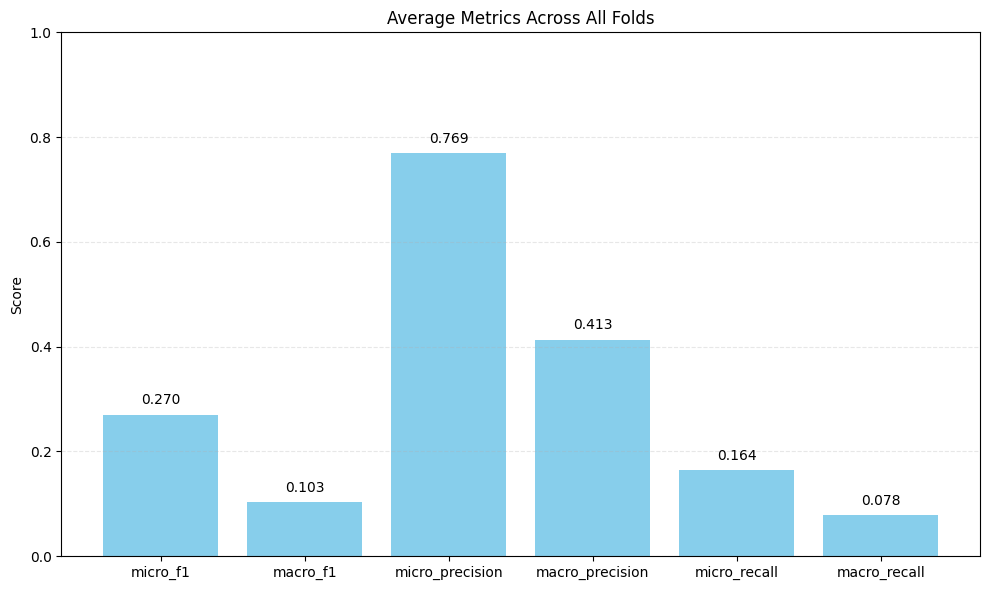

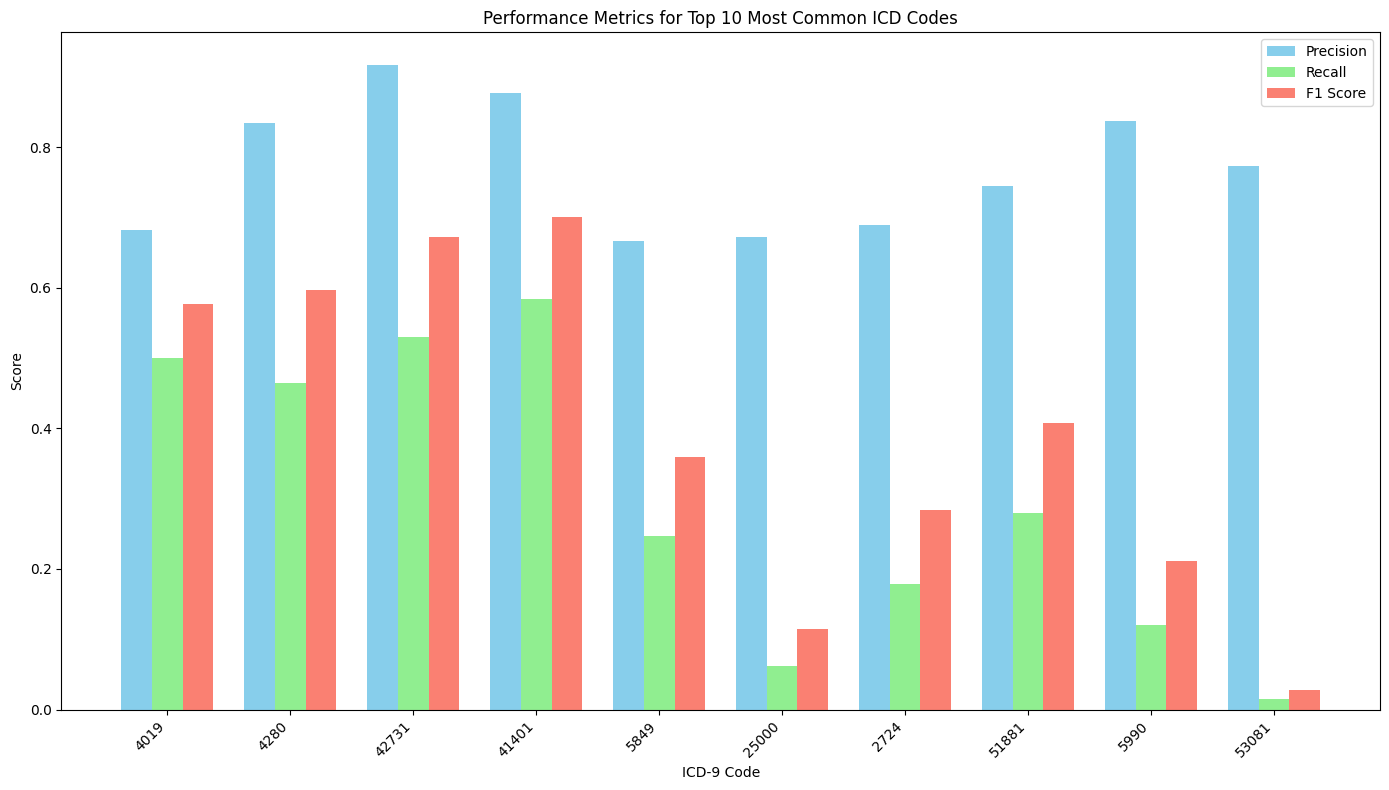

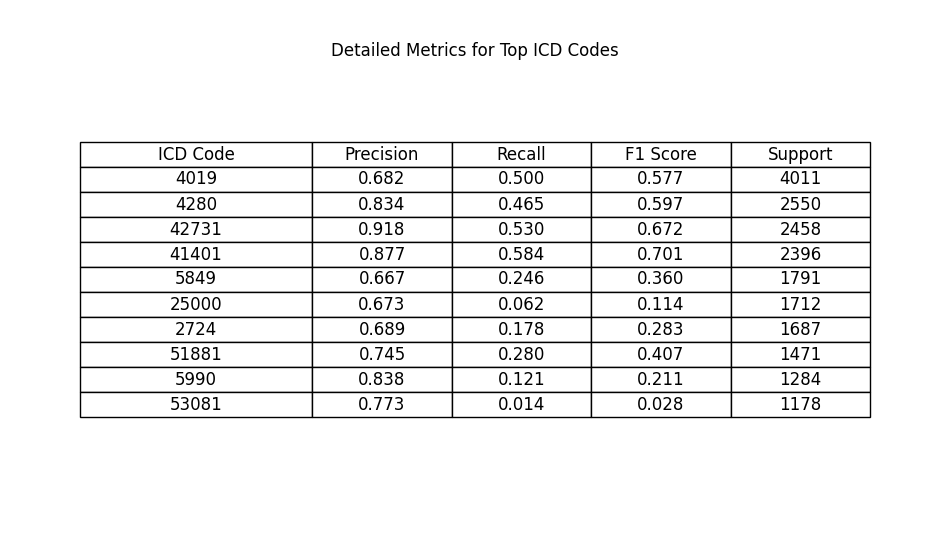

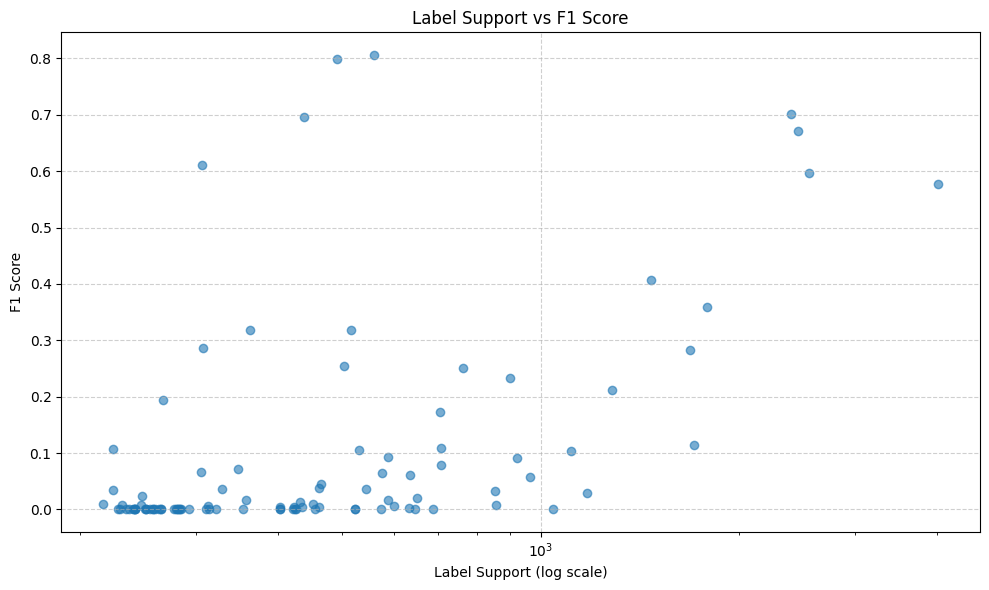

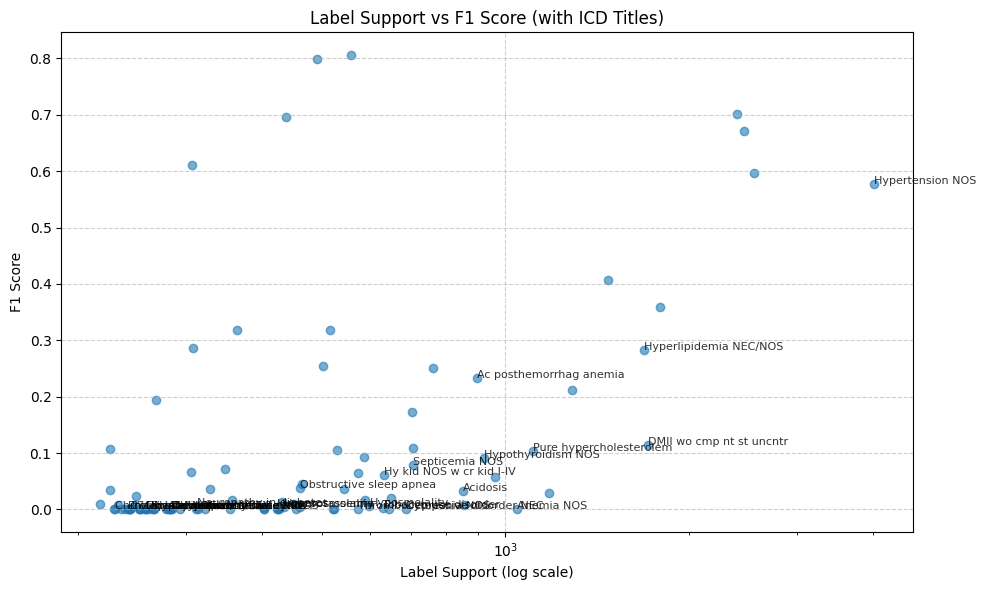

In [43]:
from sklearn.metrics import precision_score, recall_score, f1_score
import logging
import matplotlib.pyplot as plt
# === cv_results and per-class metrics ===
cv_results = pd.DataFrame([{
    'fold': 1,
    'micro_f1': micro,
    'macro_f1': macro,
    'micro_precision': precision_score(Y_val_bin, Y_val_pred, average='micro'),
    'macro_precision': precision_score(Y_val_bin, Y_val_pred, average='macro'),
    'micro_recall': recall_score(Y_val_bin, Y_val_pred, average='micro'),
    'macro_recall': recall_score(Y_val_bin, Y_val_pred, average='macro'),
}])

per_class_metrics = {}
for i, label in enumerate(mlb.classes_):
    y_true = Y_val_bin[:, i]
    y_pred = Y_val_pred[:, i]
    support = y_true.sum()
    if support == 0:
        continue
    per_class_metrics[label] = {
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'support': int(support)
    }

metrics = {'per_class_metrics': per_class_metrics}

# === 调用可视化 ===
visualize_results(cv_results, metrics, plots_dir, timestamp, icd_map_path='../data/icd9_map.csv')


In [33]:

def visualize_results(cv_results, metrics, plots_dir, timestamp, icd_map_path=None):
    logging.info("Creating visualizations...")

    # === 1. F1 Scores Across Folds ===
    plt.figure(figsize=(10, 6))
    plt.plot(cv_results['fold'], cv_results['micro_f1'], 'o-', label='Micro F1')
    plt.plot(cv_results['fold'], cv_results['macro_f1'], 'o-', label='Macro F1')
    plt.title('F1 Scores Across Folds')
    plt.xlabel('Fold')
    plt.ylabel('F1 Score')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, f"f1_scores_{timestamp}.png"))

    # === 2. All Metrics Across Folds ===
    plt.figure(figsize=(12, 8))
    metrics_to_plot = ['micro_f1', 'macro_f1', 'micro_precision', 'macro_precision', 'micro_recall', 'macro_recall']
    for metric in metrics_to_plot:
        plt.plot(cv_results['fold'], cv_results[metric], 'o-', label=metric)
    plt.title('All Metrics Across Folds')
    plt.xlabel('Fold')
    plt.ylabel('Score')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, f"all_metrics_{timestamp}.png"))

    # === 3. Average Metrics Bar Chart ===
    plt.figure(figsize=(10, 6))
    metrics_names = ['micro_f1', 'macro_f1', 'micro_precision', 'macro_precision', 'micro_recall', 'macro_recall']
    avg_values = [cv_results[m].mean() for m in metrics_names]
    plt.bar(metrics_names, avg_values, color='skyblue')
    plt.ylim(0, 1.0)
    plt.title('Average Metrics Across All Folds')
    plt.ylabel('Score')
    plt.grid(True, linestyle='--', alpha=0.3, axis='y')
    for i, v in enumerate(avg_values):
        plt.text(i, v + 0.02, f'{v:.3f}', ha='center')
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, f"avg_metrics_{timestamp}.png"))

    # === 4. Per-class Top ICD Performance ===
    if 'per_class_metrics' in metrics:
        per_class = metrics['per_class_metrics']
        codes = list(per_class.keys())
        f1_scores = [per_class[c]['f1'] for c in codes]
        precisions = [per_class[c]['precision'] for c in codes]
        recalls = [per_class[c]['recall'] for c in codes]
        supports = [per_class[c]['support'] for c in codes]

        # Sort by support
        sorted_indices = np.argsort(supports)[::-1][:10]
        codes = [codes[i] for i in sorted_indices]
        f1_scores = [f1_scores[i] for i in sorted_indices]
        precisions = [precisions[i] for i in sorted_indices]
        recalls = [recalls[i] for i in sorted_indices]

        # Bar plot
        plt.figure(figsize=(14, 8))
        x = np.arange(len(codes))
        width = 0.25
        plt.bar(x - width, precisions, width, label='Precision', color='skyblue')
        plt.bar(x, recalls, width, label='Recall', color='lightgreen')
        plt.bar(x + width, f1_scores, width, label='F1 Score', color='salmon')
        plt.xlabel('ICD-9 Code')
        plt.ylabel('Score')
        plt.title('Performance Metrics for Top 10 Most Common ICD Codes')
        plt.xticks(x, codes, rotation=45, ha='right')
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(plots_dir, f"top_codes_performance_{timestamp}.png"))

        # === 5. Table of Metrics ===
        plt.figure(figsize=(12, len(codes) * 0.5 + 2))
        plt.axis('off')
        table_data = [['ICD Code', 'Precision', 'Recall', 'F1 Score', 'Support']]
        for i in range(len(codes)):
            table_data.append([
                codes[i],
                f"{precisions[i]:.3f}",
                f"{recalls[i]:.3f}",
                f"{f1_scores[i]:.3f}",
                f"{per_class[codes[i]]['support']}"
            ])
        table = plt.table(cellText=table_data, colWidths=[0.25, 0.15, 0.15, 0.15, 0.15],
                          loc='center', cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(12)
        table.scale(1, 1.5)
        plt.title('Detailed Metrics for Top ICD Codes', y=0.9)
        plt.savefig(os.path.join(plots_dir, f"top_codes_table_{timestamp}.png"), bbox_inches='tight')

        # === 6. Support vs F1 Score Scatter Plot ===
        codes_all = list(per_class.keys())
        supports_all = [per_class[c]['support'] for c in codes_all]
        f1s_all = [per_class[c]['f1'] for c in codes_all]

        plt.figure(figsize=(10, 6))
        plt.scatter(supports_all, f1s_all, alpha=0.6)
        plt.xscale('log')
        plt.xlabel('Label Support (log scale)')
        plt.ylabel('F1 Score')
        plt.title('Label Support vs F1 Score')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.savefig(os.path.join(plots_dir, f"support_vs_f1_{timestamp}.png"))

        # Optional: use icd9_map.csv to show short titles
        if icd_map_path is not None and os.path.exists(icd_map_path):
            icd_map = pd.read_csv(icd_map_path, dtype={'ICD9_CODE': str})
            code2title = dict(zip(icd_map['ICD9_CODE'], icd_map['SHORT_TITLE']))
            plt.figure(figsize=(10, 6))
            titles = [code2title.get(c, c) for c in codes_all]
            plt.scatter(supports_all, f1s_all, alpha=0.6)
            for i, title in enumerate(titles[:30]):  # only annotate top 30
                plt.annotate(title, (supports_all[i], f1s_all[i]), fontsize=8, alpha=0.8)
            plt.xscale('log')
            plt.xlabel('Label Support (log scale)')
            plt.ylabel('F1 Score')
            plt.title('Label Support vs F1 Score (with ICD Titles)')
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.tight_layout()
            plt.savefig(os.path.join(plots_dir, f"support_vs_f1_titles_{timestamp}.png"))

    logging.info("All visualizations saved.")


Fold 1


/opt/anaconda3/envs/ribonn/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 2


/opt/anaconda3/envs/ribonn/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 3


...

Fold 4


/opt/anaconda3/envs/ribonn/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 5


/opt/anaconda3/envs/ribonn/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


   fold  micro_f1  macro_f1  micro_precision  macro_precision  micro_recall  \
0     1  0.247288  0.091196         0.772023         0.310432      0.147223   
1     2  0.253066  0.091571         0.765599         0.311682      0.151586   
2     3  0.243783  0.086621         0.777976         0.303283      0.144537   
3     4  0.249731  0.086727         0.765639         0.325904      0.149197   
4     5  0.252610  0.090206         0.748294         0.319316      0.151954   

   macro_recall  
0      0.070164  
1      0.070689  
2      0.067150  
3      0.067418  
4      0.070602  


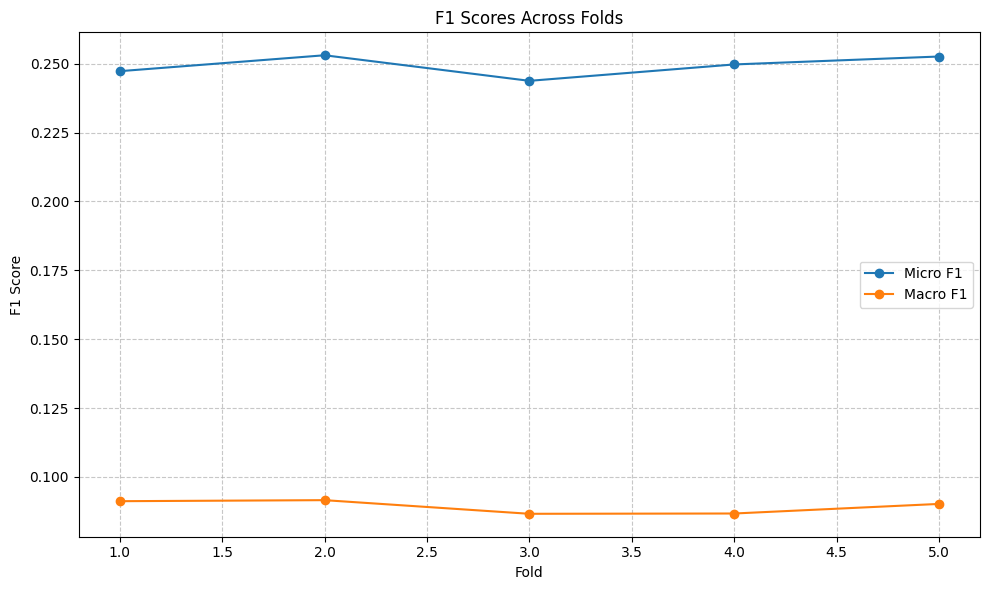

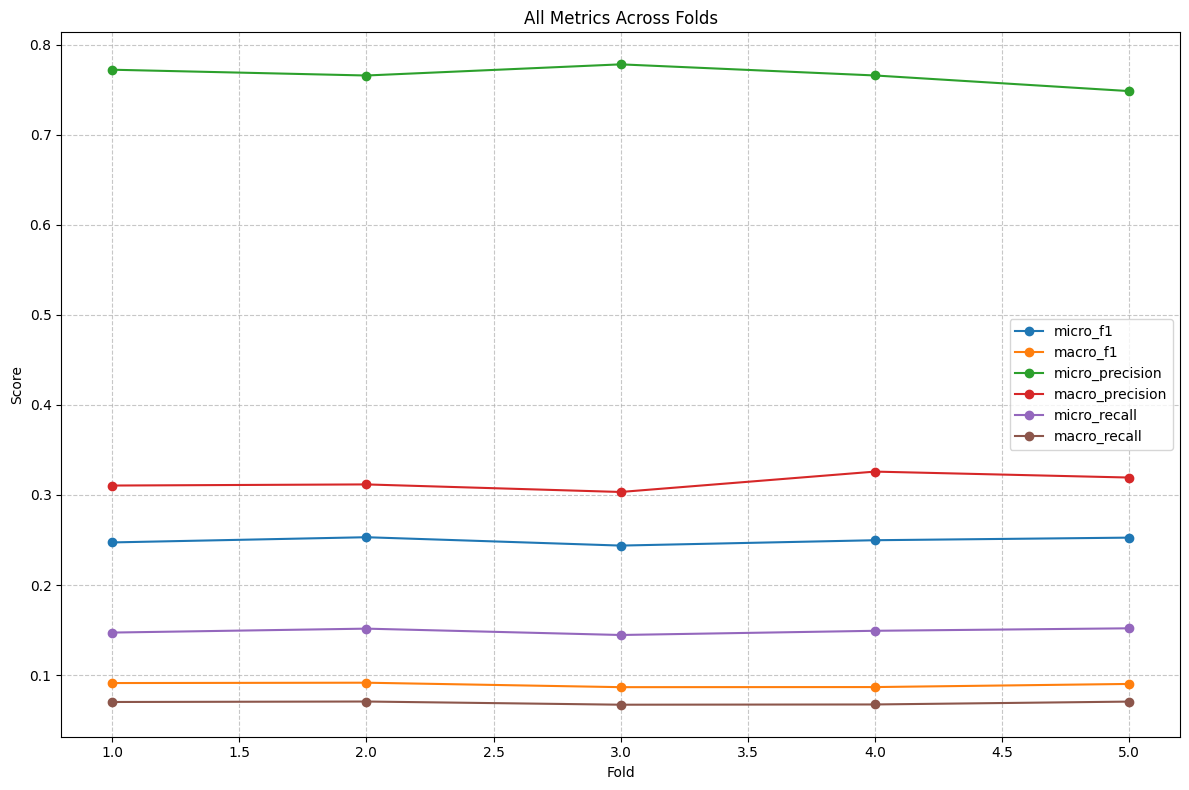

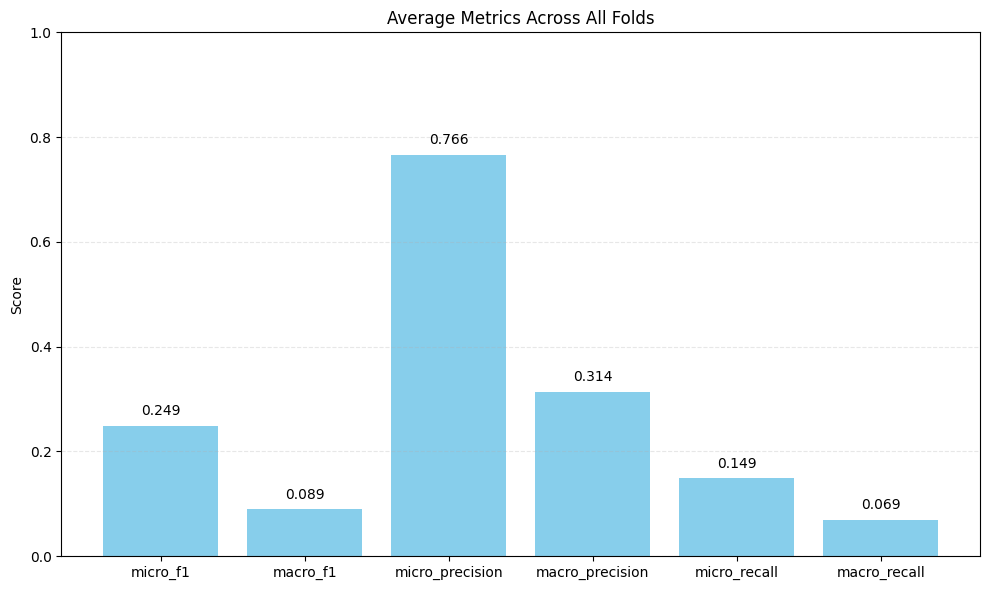

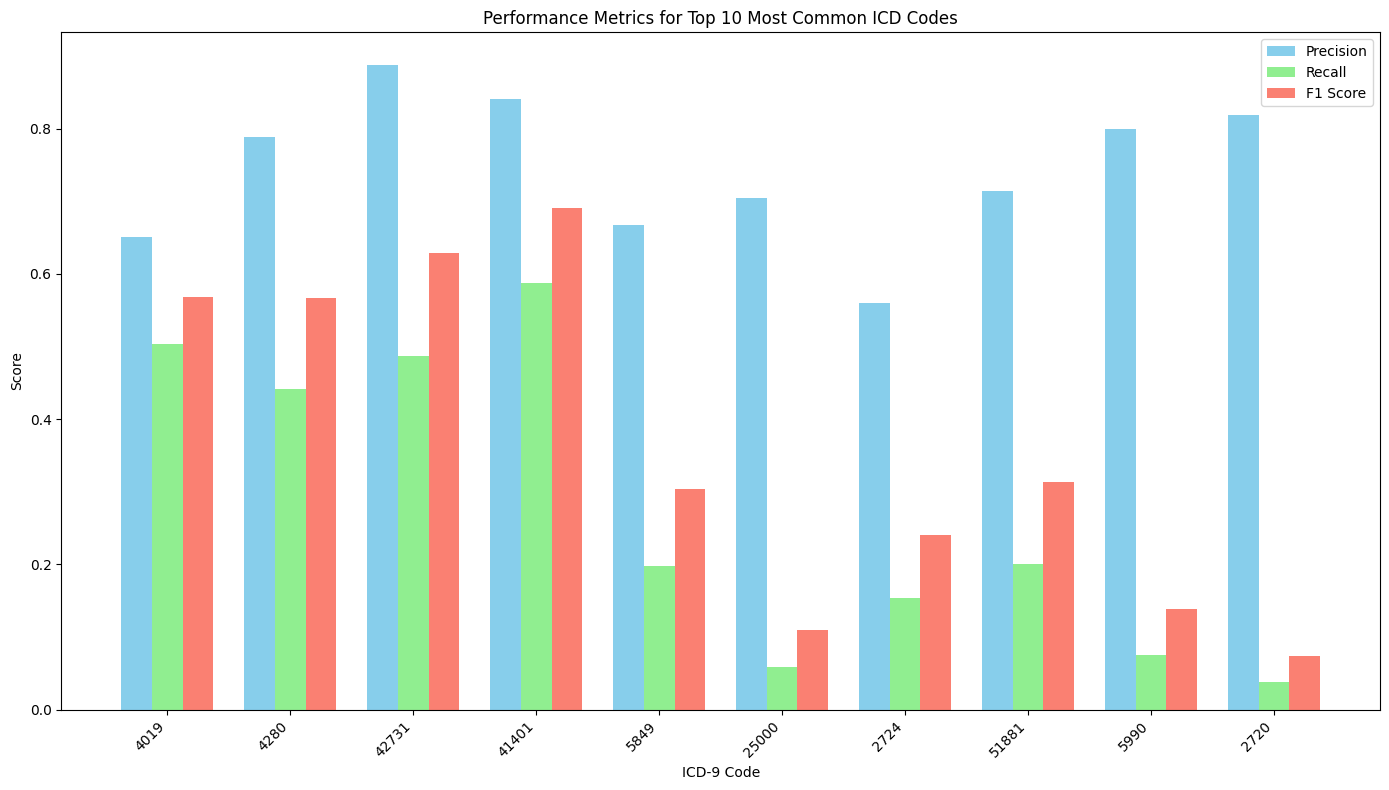

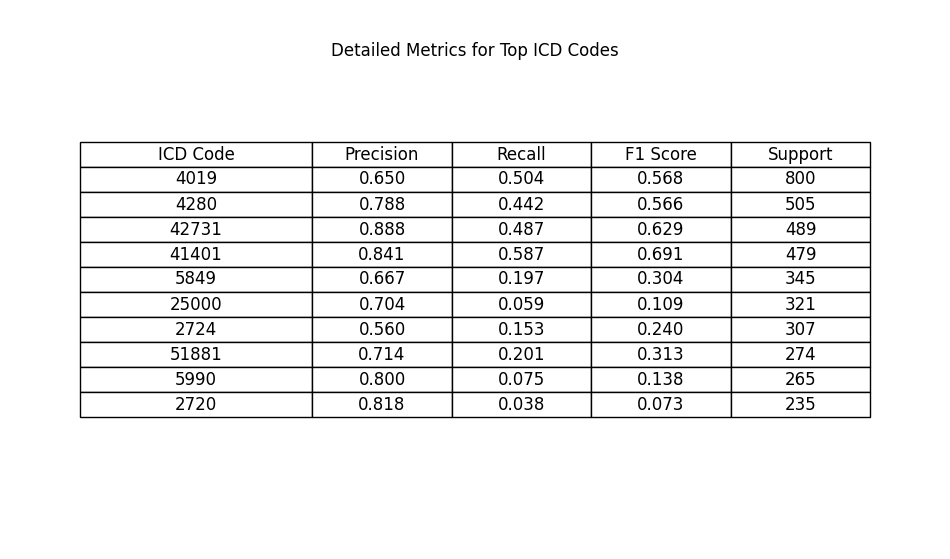

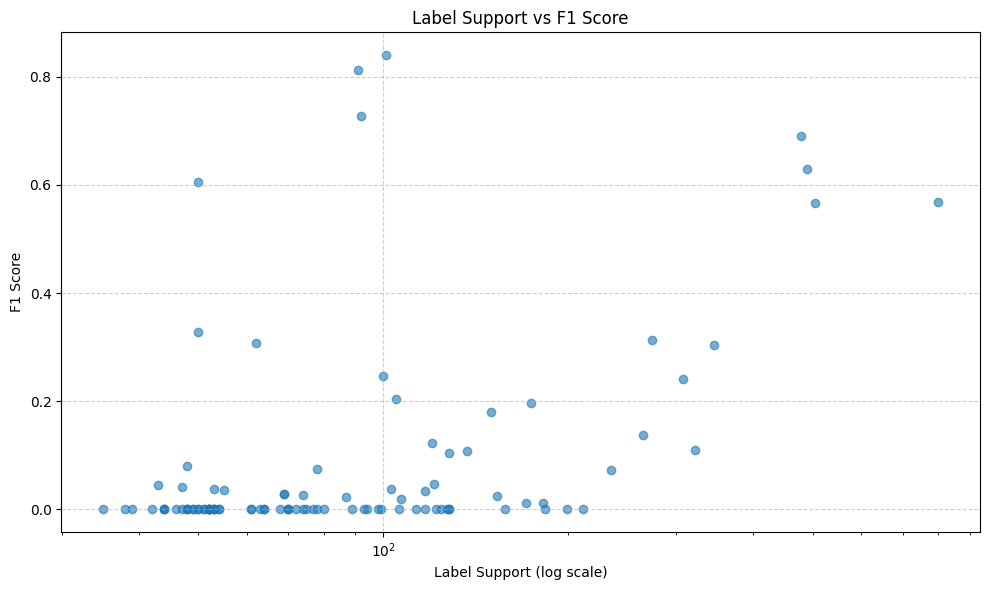

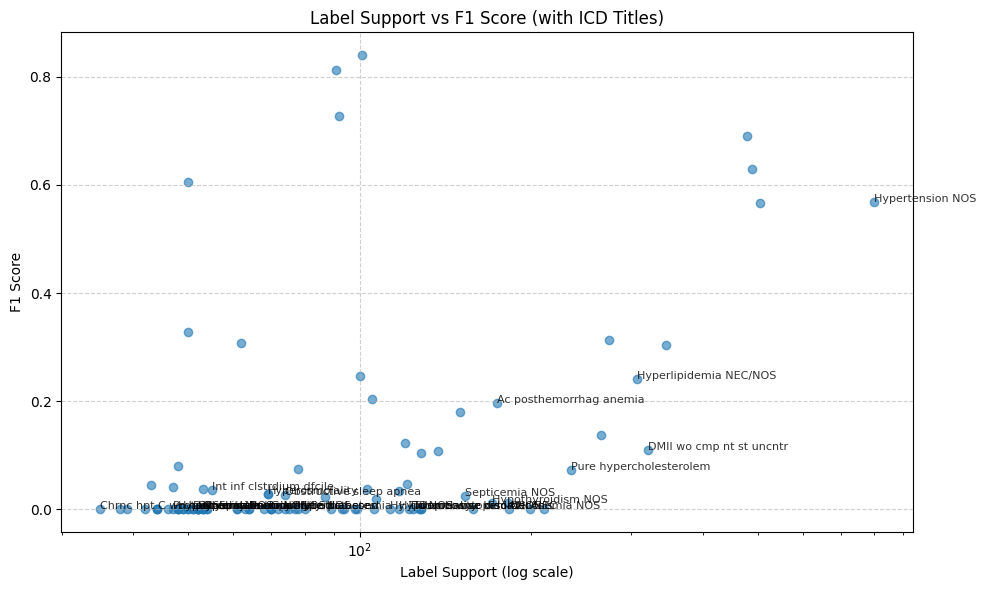

In [62]:
from sklearn.model_selection import KFold


# 准备数据
df = pd.read_pickle('../data/mimic3_data_test.pkl')
texts = df['TEXT'].tolist()
labels = df['ICD9_CODE'].tolist()

# 可选：选取 top100 标签加速
from collections import Counter
flat_labels = [l for group in labels for l in group]
top_labels = set([l for l, _ in Counter(flat_labels).most_common(100)])
filtered = [(t, [l for l in ls if l in top_labels]) for t, ls in zip(texts, labels)]
filtered = [(t, l) for t, l in filtered if len(l) > 0]

texts, labels = zip(*filtered)
texts = list(texts)
labels = list(labels)

# 可选：快速调试限制样本数量
texts = texts[:10000]
labels = labels[:10000]

# 初始化
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
metrics = {}  # 最后一折记录 per-class metrics
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
plots_dir = './plots'
os.makedirs(plots_dir, exist_ok=True)

fold = 1
for train_idx, val_idx in kf.split(texts):
    print(f"Fold {fold}")
    X_train = [texts[i] for i in train_idx]
    y_train = [labels[i] for i in train_idx]
    X_val = [texts[i] for i in val_idx]
    y_val = [labels[i] for i in val_idx]

    vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
    X_train_vec = vectorizer.fit_transform(X_train)
    X_val_vec = vectorizer.transform(X_val)

    mlb = MultiLabelBinarizer()
    Y_train_bin = mlb.fit_transform(y_train)
    Y_val_bin = mlb.transform(y_val)

    clf = OneVsRestClassifier(
        LogisticRegression(C=1.0, solver='saga', max_iter=1000),
        n_jobs=-1
    )
    clf.fit(X_train_vec, Y_train_bin)
    Y_val_pred = clf.predict(X_val_vec)

    result = {
        'fold': fold,
        'micro_f1': f1_score(Y_val_bin, Y_val_pred, average='micro'),
        'macro_f1': f1_score(Y_val_bin, Y_val_pred, average='macro'),
        'micro_precision': precision_score(Y_val_bin, Y_val_pred, average='micro'),
        'macro_precision': precision_score(Y_val_bin, Y_val_pred, average='macro'),
        'micro_recall': recall_score(Y_val_bin, Y_val_pred, average='micro'),
        'macro_recall': recall_score(Y_val_bin, Y_val_pred, average='macro'),
    }
    cv_results.append(result)

    # 最后一折记录 per-class metrics
    if fold == 5:
        per_class_metrics = {}
        for i, label in enumerate(mlb.classes_):
            y_true = Y_val_bin[:, i]
            y_pred = Y_val_pred[:, i]
            support = y_true.sum()
            if support == 0:
                continue
            per_class_metrics[label] = {
                'precision': precision_score(y_true, y_pred, zero_division=0),
                'recall': recall_score(y_true, y_pred, zero_division=0),
                'f1': f1_score(y_true, y_pred, zero_division=0),
                'support': int(support)
            }
        metrics['per_class_metrics'] = per_class_metrics

    fold += 1

# 转换为 DataFrame
cv_results = pd.DataFrame(cv_results)
print(cv_results)

visualize_results(
    cv_results=cv_results,
    metrics=metrics,
    plots_dir=plots_dir,
    timestamp=timestamp,
    icd_map_path='../data/icd9_map.csv'
)


In [56]:
print(np.__version__)

2.0.2


Fold 1


/opt/anaconda3/envs/ribonn/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 2


/opt/anaconda3/envs/ribonn/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 3


...

Fold 4


/opt/anaconda3/envs/ribonn/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 5


/opt/anaconda3/envs/ribonn/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


   fold  micro_f1  macro_f1  micro_precision  macro_precision  micro_recall  \
0     1  0.200472  0.064196         0.756396         0.166299      0.115548   
1     2  0.203239  0.063408         0.781714         0.171065      0.116803   
2     3  0.212772  0.060392         0.758014         0.161889      0.123755   
3     4  0.186451  0.058381         0.763571         0.171962      0.106190   
4     5  0.214080  0.065240         0.748739         0.196981      0.124895   

   macro_recall  
0      0.052093  
1      0.050484  
2      0.049165  
3      0.046634  
4      0.051969  


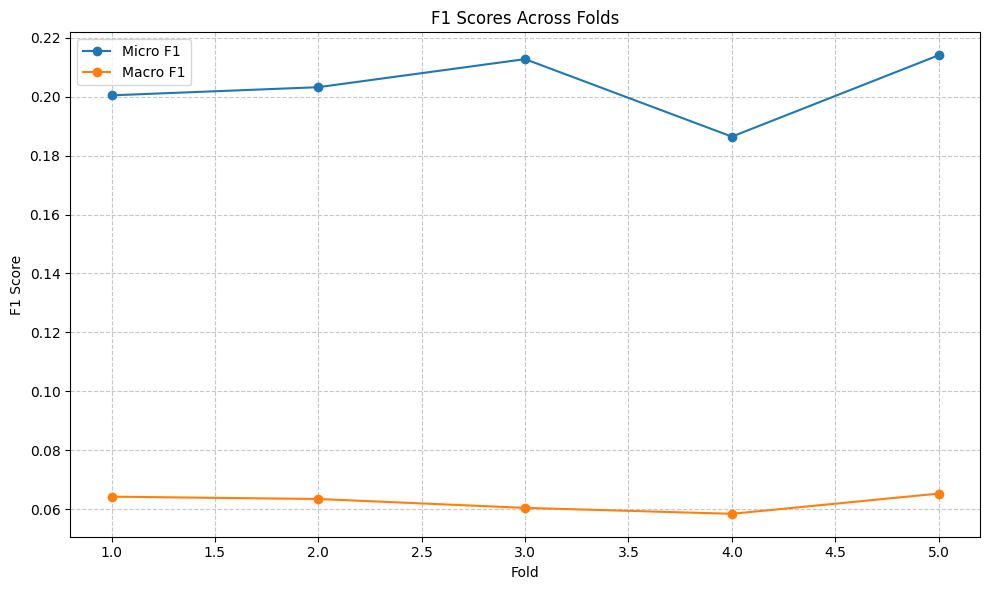

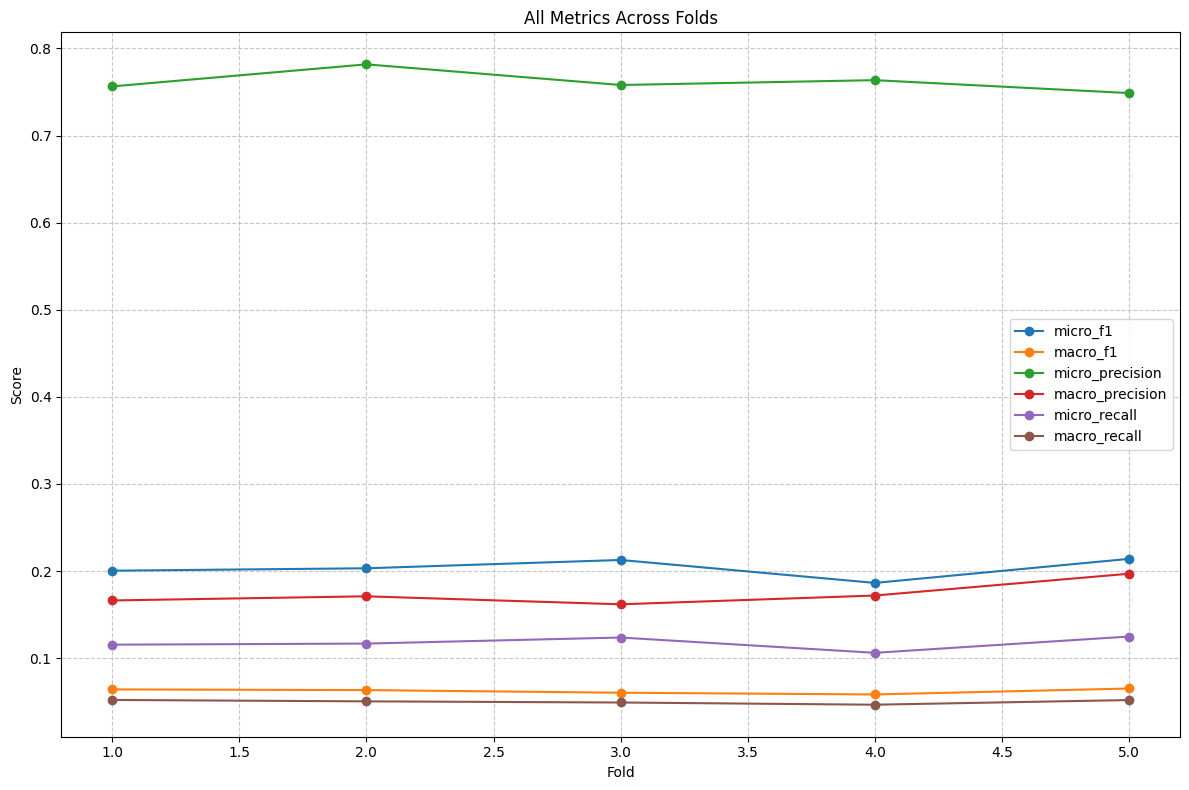

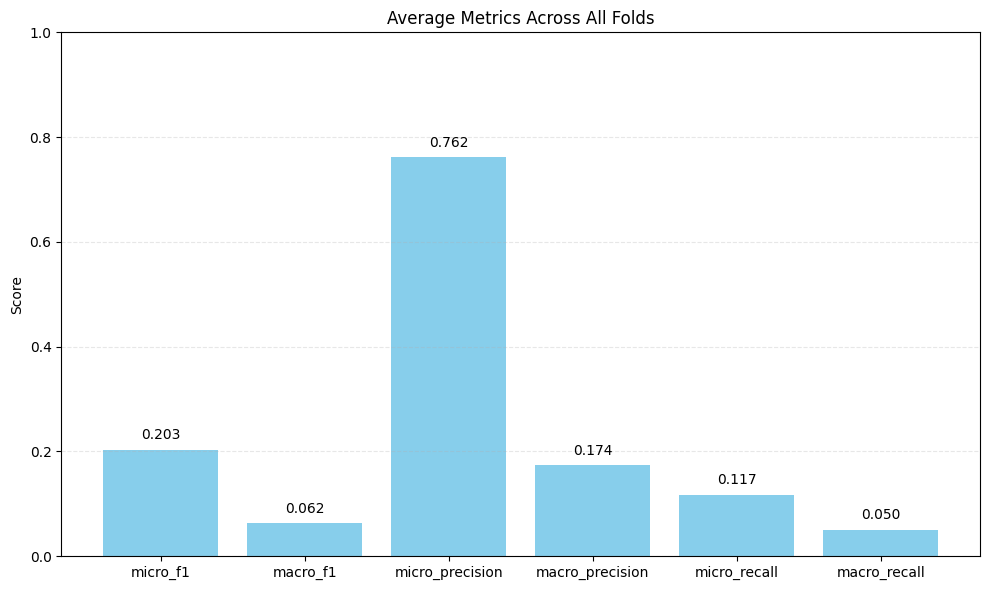

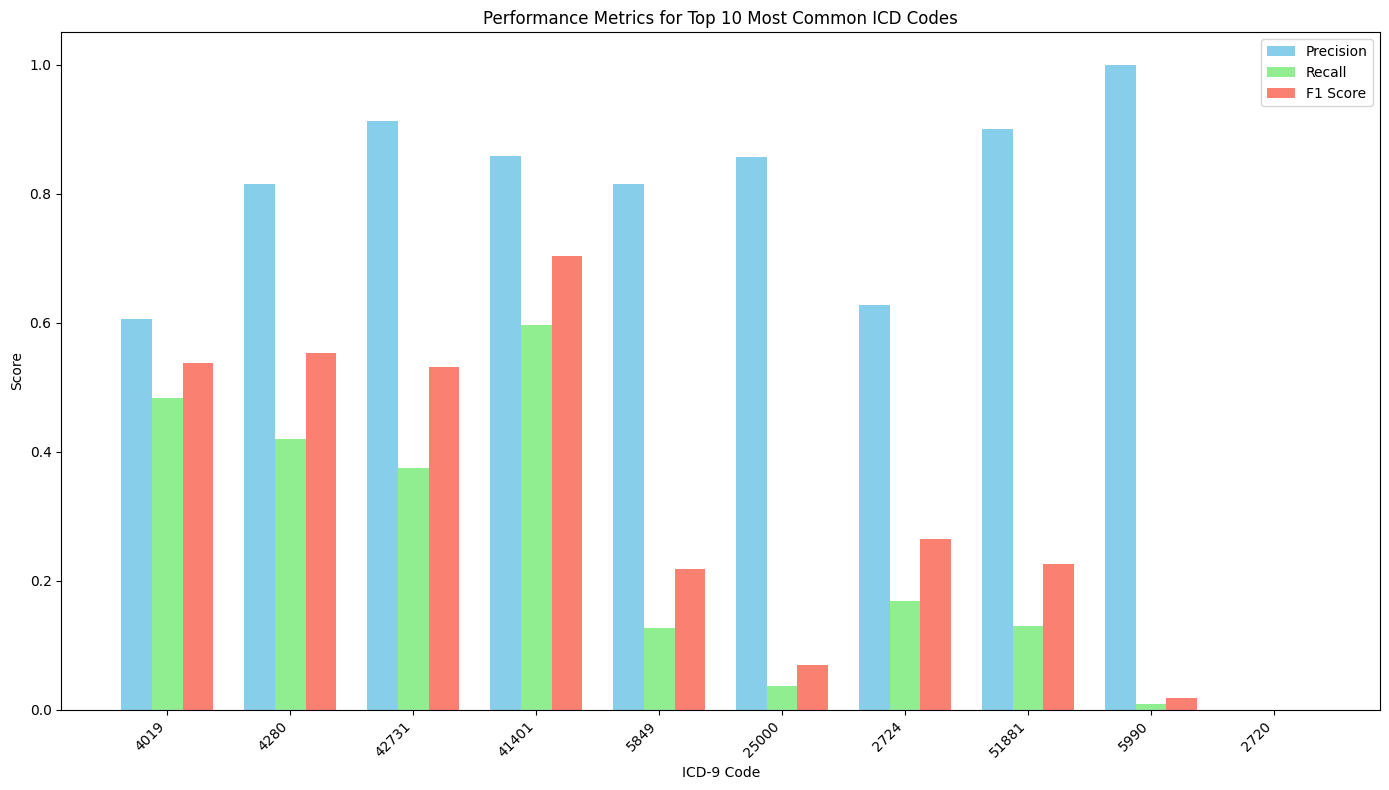

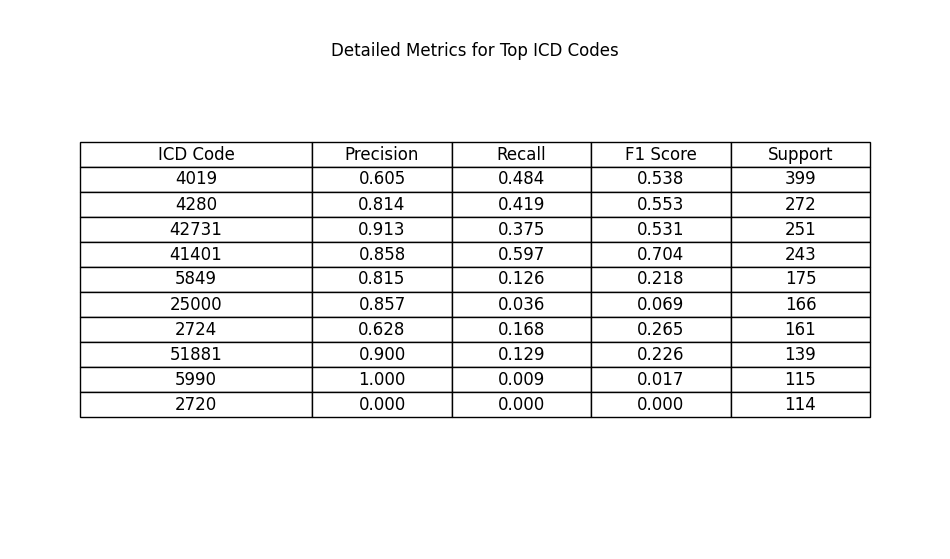

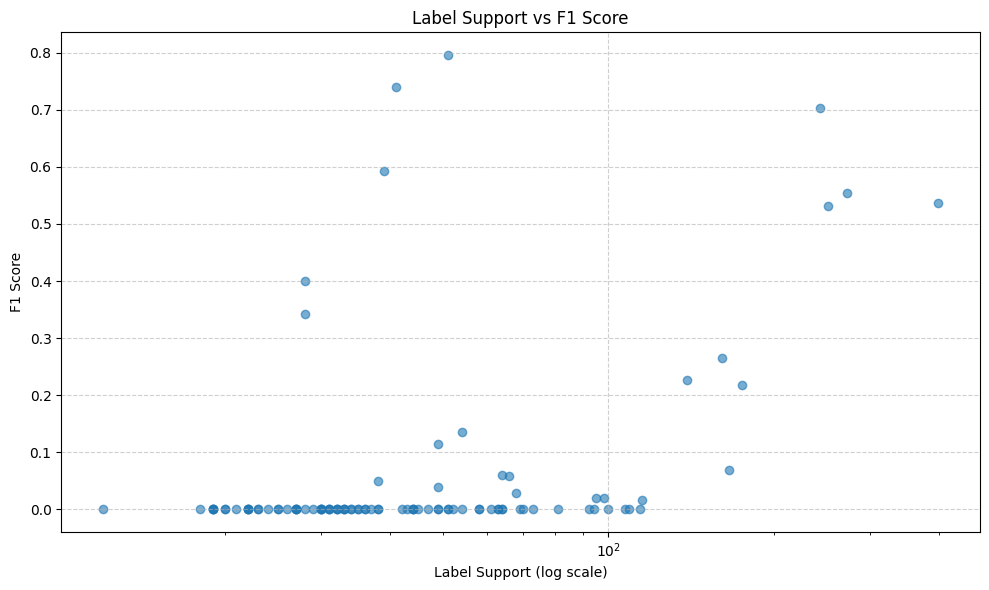

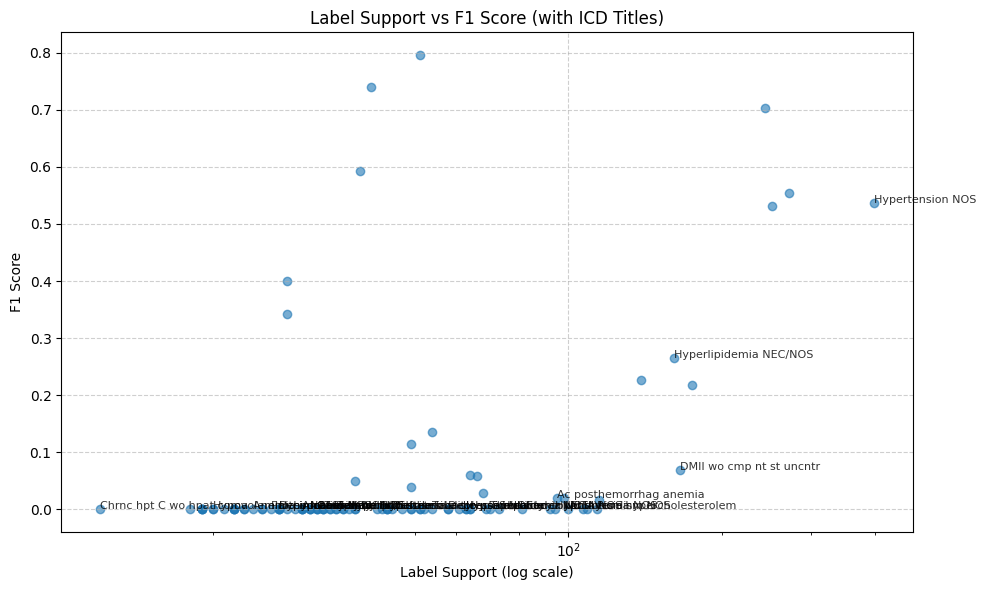

In [64]:

texts, labels = zip(*filtered)
texts = list(texts)
labels = list(labels)

texts = texts[:5000]
labels = labels[:5000]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
metrics = {}  # last folder per-class metrics
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
plots_dir = './plots'
os.makedirs(plots_dir, exist_ok=True)


fold = 1
for train_idx, val_idx in kf.split(texts):
    print(f"Fold {fold}")
    X_train = [texts[i] for i in train_idx]
    y_train = [labels[i] for i in train_idx]
    X_val = [texts[i] for i in val_idx]
    y_val = [labels[i] for i in val_idx]

    vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
    X_train_vec = vectorizer.fit_transform(X_train)
    X_val_vec = vectorizer.transform(X_val)

    mlb = MultiLabelBinarizer()
    Y_train_bin = mlb.fit_transform(y_train)
    Y_val_bin = mlb.transform(y_val)

    clf = OneVsRestClassifier(
        LogisticRegression(C=1.0, solver='saga', max_iter=1000),
        n_jobs=-1
    )
    clf.fit(X_train_vec, Y_train_bin)
    Y_val_pred = clf.predict(X_val_vec)

    result = {
        'fold': fold,
        'micro_f1': f1_score(Y_val_bin, Y_val_pred, average='micro'),
        'macro_f1': f1_score(Y_val_bin, Y_val_pred, average='macro'),
        'micro_precision': precision_score(Y_val_bin, Y_val_pred, average='micro'),
        'macro_precision': precision_score(Y_val_bin, Y_val_pred, average='macro'),
        'micro_recall': recall_score(Y_val_bin, Y_val_pred, average='micro'),
        'macro_recall': recall_score(Y_val_bin, Y_val_pred, average='macro'),
    }
    cv_results.append(result)

    # 最后一折记录 per-class metrics
    if fold == 5:
        per_class_metrics = {}
        for i, label in enumerate(mlb.classes_):
            y_true = Y_val_bin[:, i]
            y_pred = Y_val_pred[:, i]
            support = y_true.sum()
            if support == 0:
                continue
            per_class_metrics[label] = {
                'precision': precision_score(y_true, y_pred, zero_division=0),
                'recall': recall_score(y_true, y_pred, zero_division=0),
                'f1': f1_score(y_true, y_pred, zero_division=0),
                'support': int(support)
            }
        metrics['per_class_metrics'] = per_class_metrics

    fold += 1

# convert to DataFrame
cv_results = pd.DataFrame(cv_results)
print(cv_results)

visualize_results(
    cv_results=cv_results,
    metrics=metrics,
    plots_dir=plots_dir,
    timestamp=timestamp,
    icd_map_path='../data/icd9_map.csv'
)


Fold 1


/opt/anaconda3/envs/ribonn/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 2


/opt/anaconda3/envs/ribonn/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 3


...

Fold 4


/opt/anaconda3/envs/ribonn/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 5


/opt/anaconda3/envs/ribonn/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


   fold  micro_f1  macro_f1  micro_precision  macro_precision  micro_recall  \
0     1  0.113057  0.028295         0.855422         0.063747      0.060529   
1     2  0.085271  0.024284         0.705128         0.059939      0.045380   
2     3  0.083333  0.023591         0.710526         0.064590      0.044262   
3     4  0.089623  0.022006         0.695122         0.056831      0.047899   
4     5  0.079491  0.018513         0.675676         0.049762      0.042230   

   macro_recall  
0      0.020877  
1      0.019504  
2      0.015586  
3      0.016718  
4      0.012361  


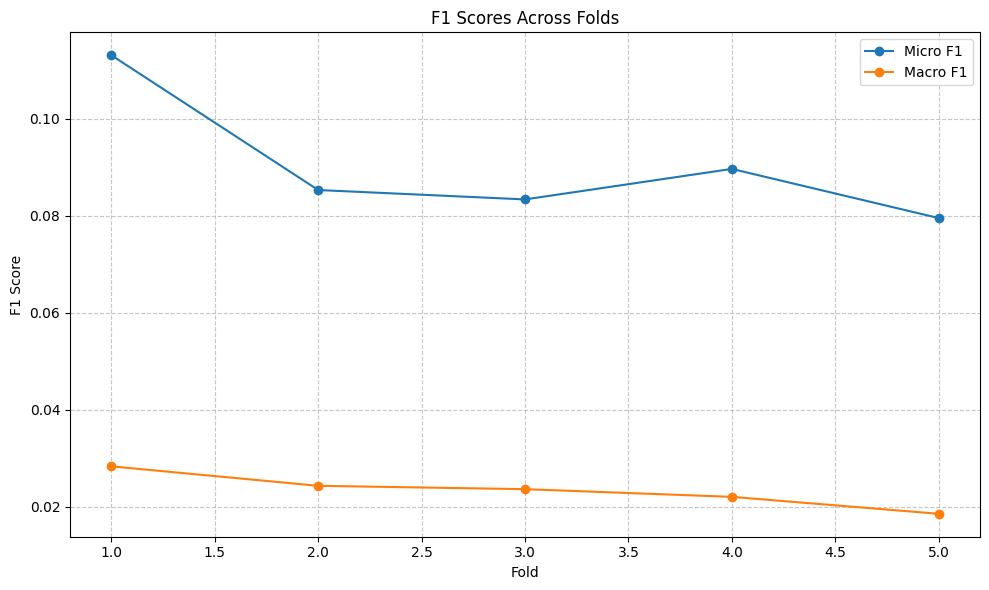

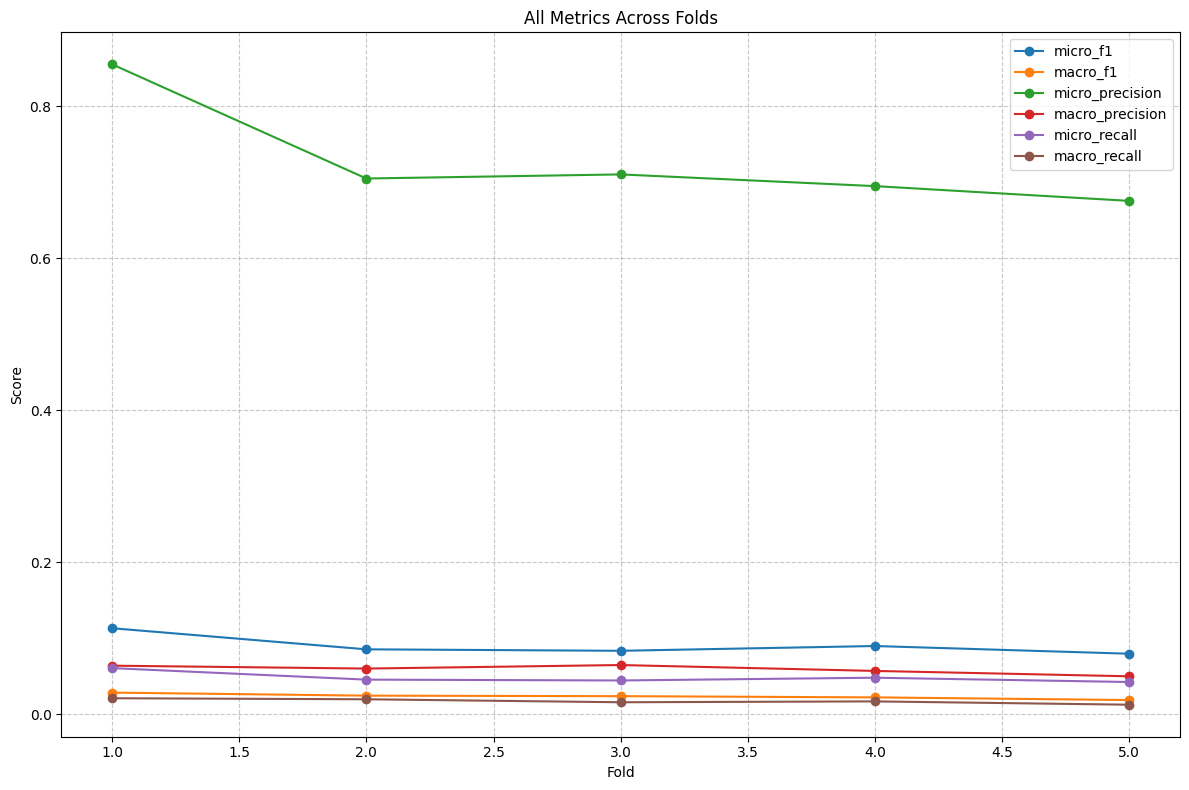

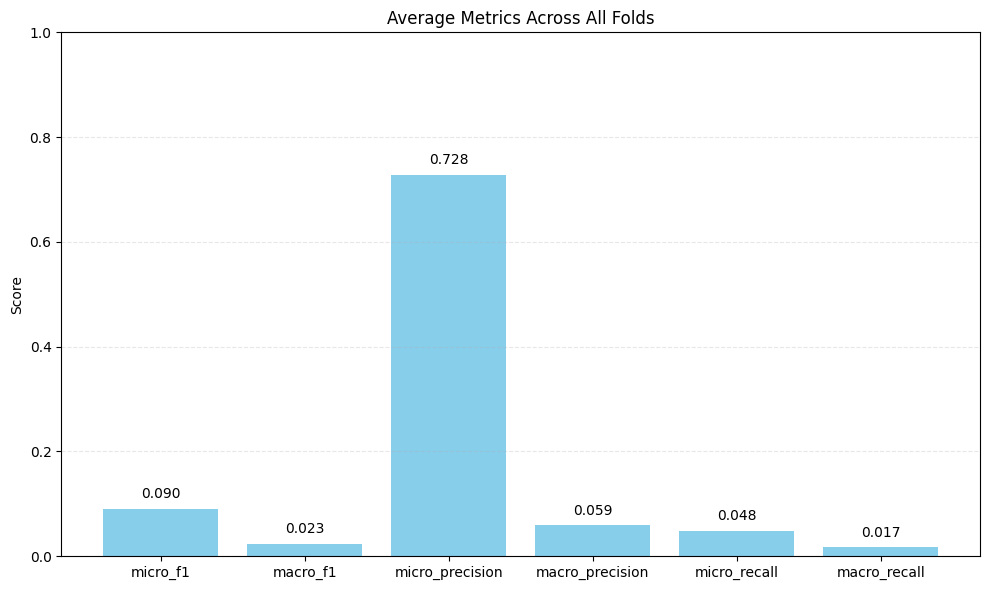

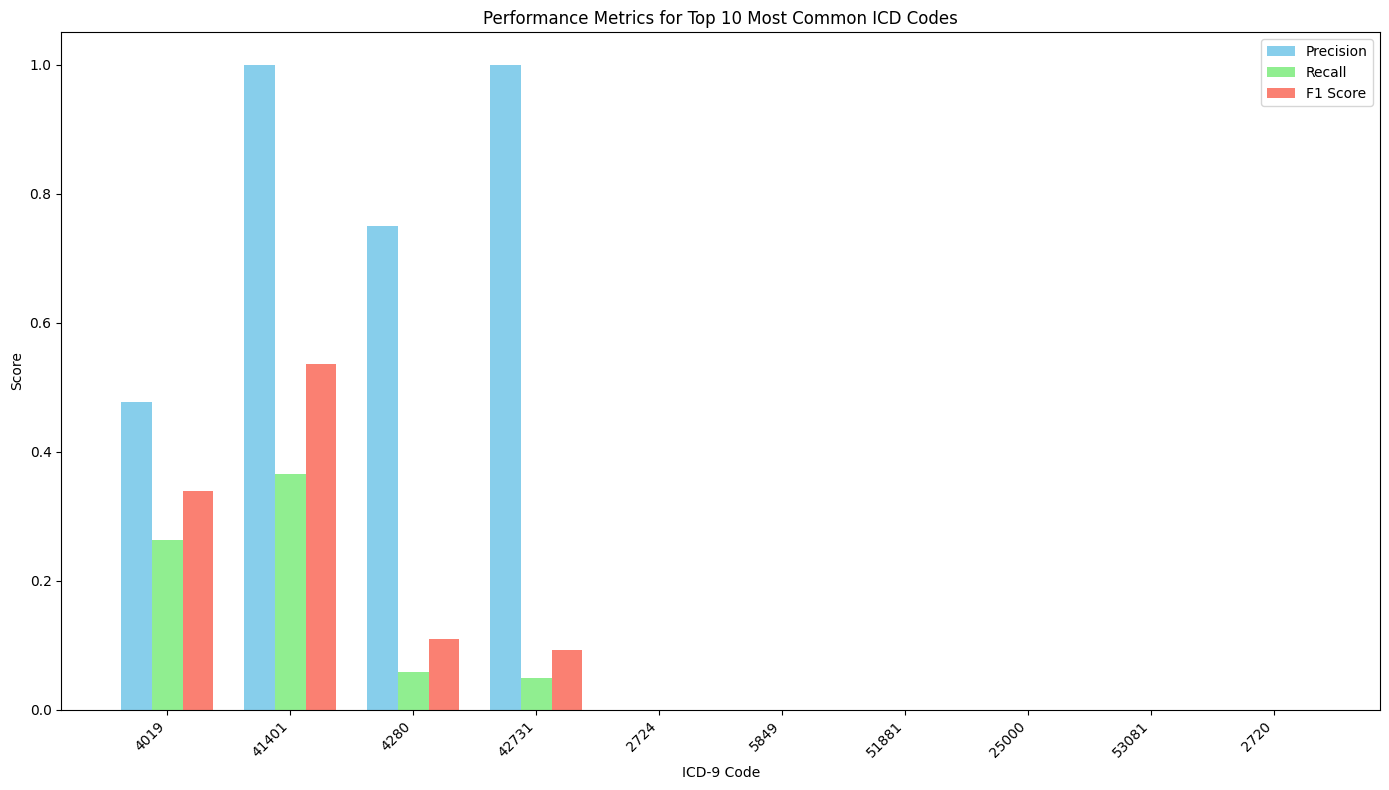

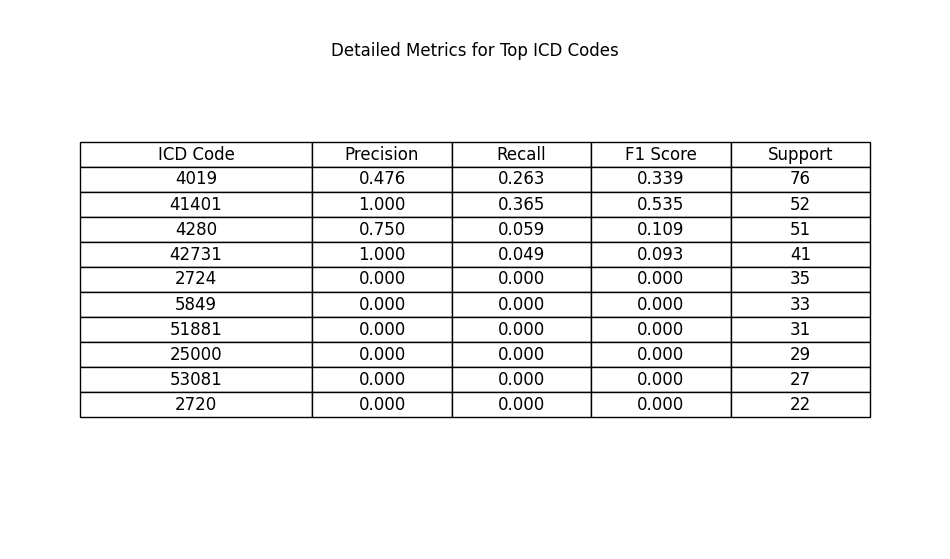

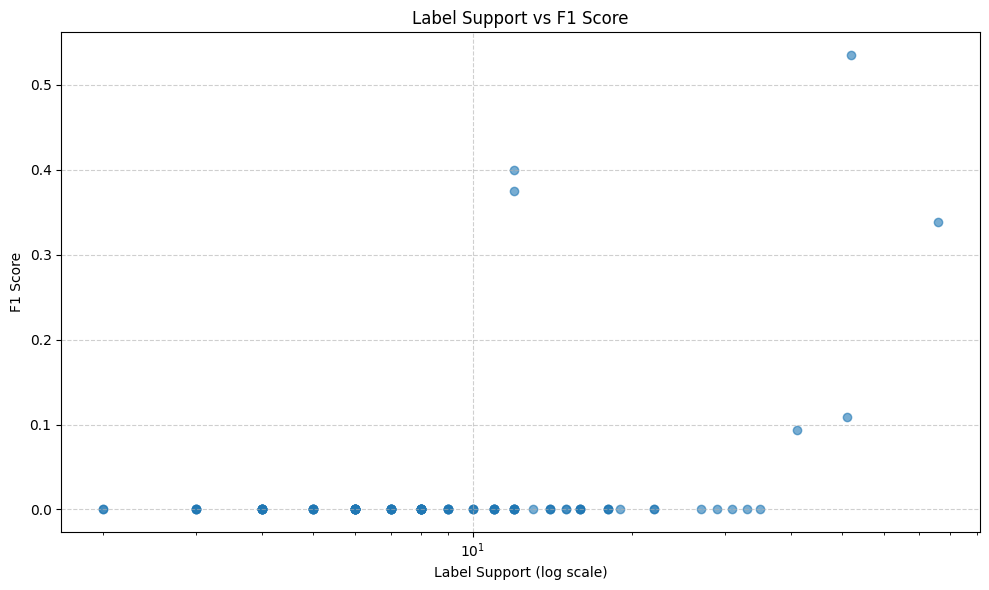

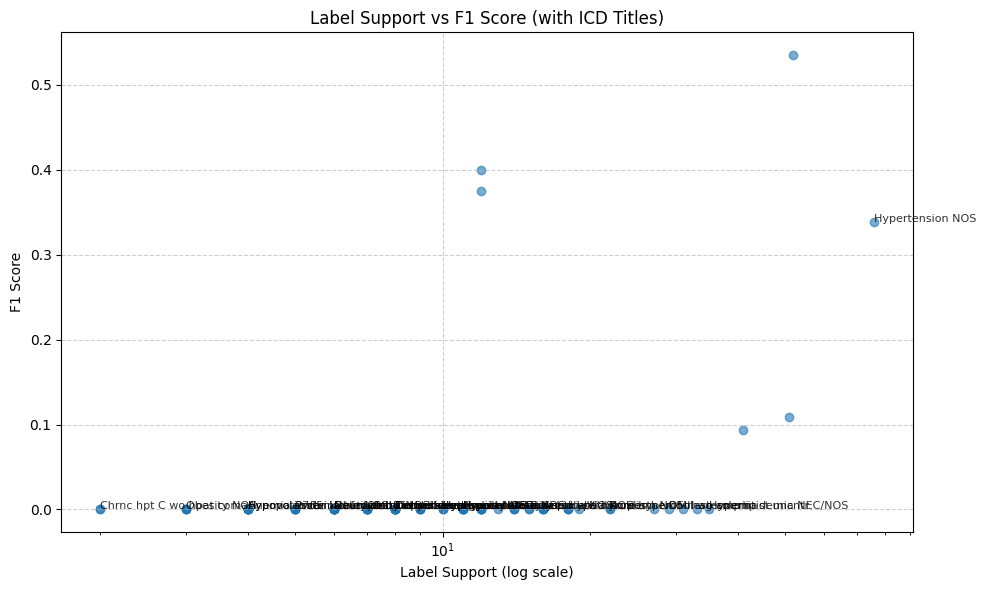

In [66]:

texts, labels = zip(*filtered)
texts = list(texts)
labels = list(labels)

texts = texts[:1000]
labels = labels[:1000]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
metrics = {} 
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
plots_dir = './plots'
os.makedirs(plots_dir, exist_ok=True)

fold = 1
for train_idx, val_idx in kf.split(texts):
    print(f"Fold {fold}")
    X_train = [texts[i] for i in train_idx]
    y_train = [labels[i] for i in train_idx]
    X_val = [texts[i] for i in val_idx]
    y_val = [labels[i] for i in val_idx]

    vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
    X_train_vec = vectorizer.fit_transform(X_train)
    X_val_vec = vectorizer.transform(X_val)

    mlb = MultiLabelBinarizer()
    Y_train_bin = mlb.fit_transform(y_train)
    Y_val_bin = mlb.transform(y_val)

    clf = OneVsRestClassifier(
        LogisticRegression(C=1.0, solver='saga', max_iter=1000),
        n_jobs=-1
    )
    clf.fit(X_train_vec, Y_train_bin)
    Y_val_pred = clf.predict(X_val_vec)

    result = {
        'fold': fold,
        'micro_f1': f1_score(Y_val_bin, Y_val_pred, average='micro'),
        'macro_f1': f1_score(Y_val_bin, Y_val_pred, average='macro'),
        'micro_precision': precision_score(Y_val_bin, Y_val_pred, average='micro'),
        'macro_precision': precision_score(Y_val_bin, Y_val_pred, average='macro'),
        'micro_recall': recall_score(Y_val_bin, Y_val_pred, average='micro'),
        'macro_recall': recall_score(Y_val_bin, Y_val_pred, average='macro'),
    }
    cv_results.append(result)

    # 最后一折记录 per-class metrics
    if fold == 5:
        per_class_metrics = {}
        for i, label in enumerate(mlb.classes_):
            y_true = Y_val_bin[:, i]
            y_pred = Y_val_pred[:, i]
            support = y_true.sum()
            if support == 0:
                continue
            per_class_metrics[label] = {
                'precision': precision_score(y_true, y_pred, zero_division=0),
                'recall': recall_score(y_true, y_pred, zero_division=0),
                'f1': f1_score(y_true, y_pred, zero_division=0),
                'support': int(support)
            }
        metrics['per_class_metrics'] = per_class_metrics

    fold += 1

cv_results = pd.DataFrame(cv_results)
print(cv_results)

visualize_results(
    cv_results=cv_results,
    metrics=metrics,
    plots_dir=plots_dir,
    timestamp=timestamp,
    icd_map_path='../data/icd9_map.csv'
)